# Show the new data.

The new data are time series of oscillation frequency and power. We measured power at two differnet frequency "bands": a "Canonical oscillation band", and a "low-freqeuncy band". This is because some data showed not just single-frequency oscillations, but double-frequency oscillations. This is unusual for the kidney blood flow oscillations, so we decided to look at the two bands separately. The low-frequency band can be explained based on earlier few publications: possibly it is a subharmonic of the Canonical band (often half the frequency of the canonical band, but not always). We don't have a proof that it is the same process, that's why we decided to look at them separately. 

First of all, we want to look at the canonical band.

In [67]:
import xarray as xr
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def gb_xr(data, **kwgs):
    return xr.DataArray(gaussian_filter1d(data.data, **kwgs), dims=data.dims, coords=data.coords)

In [6]:
data = xr.open_datatree('../data/raw/time_series_empa.nc') # All data from the recording with emagliflozin injection (there is another one for vehicle injection)

In [7]:
data

<xarray.DataTree>
Group: /
├── Group: /20241011a
│       Dimensions:         (vessel: 26, band: 2, t: 4215)
│       Coordinates:
│         * vessel          (vessel) int32 104B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28
│           activity_type   (vessel) <U6 624B ...
│         * band            (band) <U9 72B 'canonical' 'lowfreq'
│         * t               (t) float64 34kB -425.5 -425.0 ... 1.681e+03 1.682e+03
│       Data variables:
│           power_norm      (vessel, band, t) float64 2MB ...
│           frequency       (vessel, band, t) float64 2MB ...
│           bfi_gb          (vessel, t) float32 438kB ...
│           bfi_orig        (vessel, t) float32 438kB ...
│           blood_pressure  (t) float32 17kB ...
│       Attributes:
│           rat:        20241011a
│           treatment:  empa
│           gtyp:       fa/+
│           age:        Adult
│           sex:        F
├── Group: /20241011b
│       Dimensions:         (vessel: 28, band: 2, t: 3569)
│       Coordinates:
│         * vessel          (vessel) int32 112B 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 29
│           activity_type   (vessel) <U12 1kB ...
│         * band            (band) <U9 72B 'canonical' 'lowfreq'
│         * t               (t) float64 29kB -170.5 -170.0 ... 1.613e+03 1.614e+03
│       Data variables:
│           power_norm      (vessel, band, t) float64 2MB ...
│           frequency       (vessel, band, t) float64 2MB ...
│           bfi_gb          (vessel, t) float32 400kB ...
│           bfi_orig        (vessel, t) float32 400kB ...
│           blood_pressure  (t) float32 14kB ...
│       Attributes:
│           rat:        20241011b
│           treatment:  empa
│           gtyp:       fa/+
│           age:        Adult
│           sex:        F
├── Group: /20241014a
│       Dimensions:         (vessel: 31, band: 2, t: 3647)
│       Coordinates:
│         * vessel          (vessel) int32 124B 0 1 2 3 4 5 6 7 ... 25 26 27 28 29 30 31
│           activity_type   (vessel) <U12 1kB ...
│         * band            (band) <U9 72B 'canonical' 'lowfreq'
│         * t               (t) float64 29kB -234.5 -234.0 ... 1.588e+03 1.588e+03
│       Data variables:
│           power_norm      (vessel, band, t) float64 2MB ...
│           frequency       (vessel, band, t) float64 2MB ...
│           bfi_gb          (vessel, t) float32 452kB ...
│           bfi_orig        (vessel, t) float32 452kB ...
│           blood_pressure  (t) float32 15kB ...
│       Attributes:
│           rat:        20241014a
│           treatment:  empa
│           gtyp:       fa/+
│           age:        Adult
│           sex:        F
├── Group: /20241014b
│       Dimensions:         (vessel: 21, band: 2, t: 3837)
│       Coordinates:
│         * vessel          (vessel) int32 84B 0 1 2 3 4 5 6 7 ... 14 15 16 17 18 19 20
│           activity_type   (vessel) <U12 1kB ...
│         * band            (band) <U9 72B 'canonical' 'lowfreq'
│         * t               (t) float64 31kB -270.5 -270.0 ... 1.647e+03 1.648e+03
│       Data variables:
│           power_norm      (vessel, band, t) float64 1MB ...
│           frequency       (vessel, band, t) float64 1MB ...
│           bfi_gb          (vessel, t) float32 322kB ...
│           bfi_orig        (vessel, t) float32 322kB ...
│           blood_pressure  (t) float32 15kB ...
│       Attributes:
│           rat:        20241014b
│           treatment:  empa
│           gtyp:       fa/+
│           age:        Adult
│           sex:        M
├── Group: /20241015a
│       Dimensions:         (vessel: 26, band: 2, t: 4024)
│       Coordinates:
│         * vessel          (vessel) int32 104B 0 1 2 3 4 5 6 7 ... 19 20 21 22 23 24 25
│           activity_type   (vessel) <U12 1kB ...
│         * band            (band) <U9 72B 'canonical' 'lowfreq'
│         * t               (t) float64 32kB -412.0 -411.5 -411.0 ... 1.599e+03 1.6e+03
│       Data variables:
│           power_norm      (vessel, band, t) float64 2MB ...
│           fr

In [12]:
# works like a dictionary
data['20240821a'] # All data for rat 20240821a

<xarray.DataTree '20240821a'>
Group: /20240821a
    Dimensions:         (vessel: 22, band: 2, t: 4079)
    Coordinates:
      * vessel          (vessel) int32 88B 0 1 2 3 6 7 8 9 ... 17 18 19 20 21 22 23
        activity_type   (vessel) <U12 1kB ...
      * band            (band) <U9 72B 'canonical' 'lowfreq'
      * t               (t) float64 33kB -266.0 -265.5 ... 1.772e+03 1.773e+03
    Data variables:
        power_norm      (vessel, band, t) float64 1MB ...
        frequency       (vessel, band, t) float64 1MB ...
        bfi_gb          (vessel, t) float32 359kB ...
        bfi_orig        (vessel, t) float32 359kB ...
        blood_pressure  (t) float32 16kB ...
    Attributes:
        rat:        20240821a
        treatment:  empa
        gtyp:       fa/fa
        age:        Young
        sex:        M

In [108]:
# Convert to dataset to access all variables, just like with any other xr.dataset
data_rat = data['20240821a'].to_dataset() # alternatively, .ds method
data_rat

<xarray.Dataset> Size: 4MB
Dimensions:         (vessel: 22, band: 2, t: 4079)
Coordinates:
  * vessel          (vessel) int32 88B 0 1 2 3 6 7 8 9 ... 17 18 19 20 21 22 23
    activity_type   (vessel) <U12 1kB ...
  * band            (band) <U9 72B 'canonical' 'lowfreq'
  * t               (t) float64 33kB -266.0 -265.5 ... 1.772e+03 1.773e+03
Data variables:
    power_norm      (vessel, band, t) float64 1MB ...
    frequency       (vessel, band, t) float64 1MB ...
    bfi_gb          (vessel, t) float32 359kB ...
    bfi_orig        (vessel, t) float32 359kB 43.22 61.11 50.41 ... 62.19 61.91
    blood_pressure  (t) float32 16kB ...
Attributes:
    rat:        20240821a
    treatment:  empa
    gtyp:       fa/fa
    age:        Young
    sex:        M

# Variables:
1) Power_norm: this is normalized wavelet power. To compute it, a dominant ridge was localized in time-frequency space of the wavelet scalogram. Then the wavelet power (density) was integrated along frequency in a time-varying 20%-band around the ridge peak. Noise power was computed as mean wavelet power in frequency band where no oscillations were observed (white noise flat spectrum), 0.2-0.6 Hz, which was multiplied by the width of the time-varying band. Power_norm is the ridge power divided by the noise power. available for two bands: canonical and lowfreq
2) frequency: ridge frequency. Available for two bands: canonical and lowfreq
3) bfi_orig: original BFI time series
4) blood_pressure : one time series per rat

Attributes contain metadata

## Show BFI time series and power of BFI oscillation for one vessel

[Text(0, 0.5, 'Norm. Power'), Text(0.5, 0, 'Time (s)')]

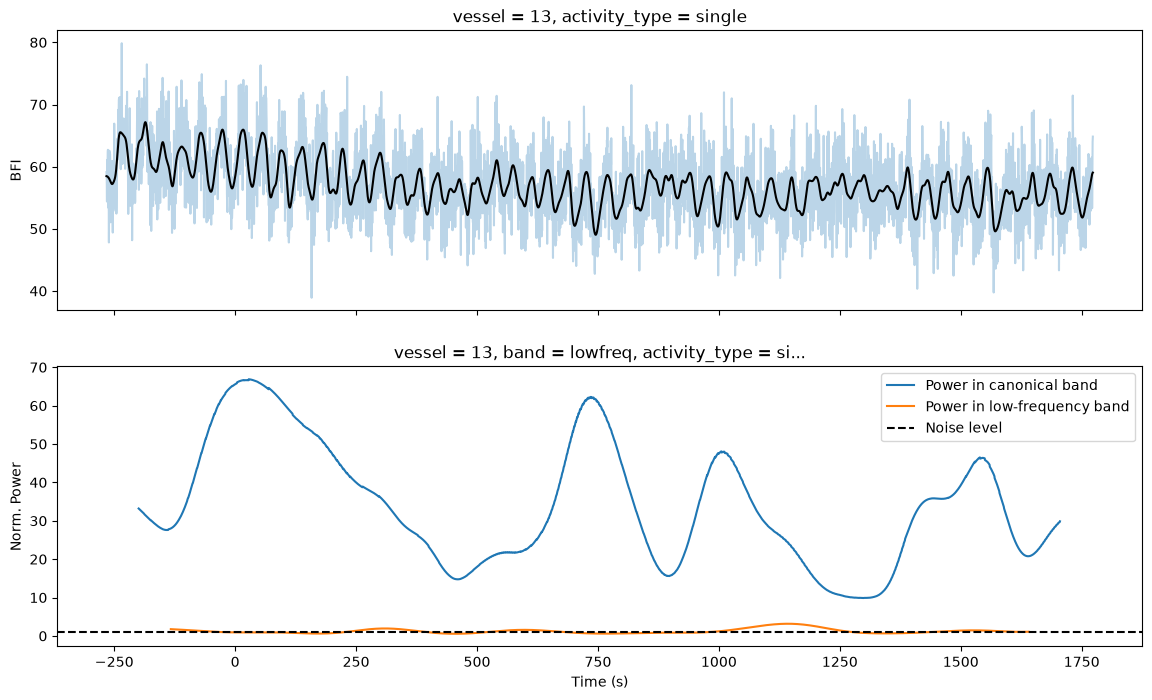

In [112]:
f, (ax,ax1) = plt.subplots(2,1, figsize=(14,8), sharex=True)
vessel_idx = 13
data_rat['bfi_orig'].sel(vessel=vessel_idx).plot(ax=ax, alpha=0.3)
gb_xr(data_rat['bfi_orig'].sel(vessel=vessel_idx), sigma=7).plot(ax=ax, color='k')
data_rat['power_norm'].sel(vessel=vessel_idx, band='canonical').plot(ax=ax1, label='Power in canonical band')
data_rat['power_norm'].sel(vessel=vessel_idx, band='lowfreq').plot(ax=ax1,label='Power in low-frequency band')

ax1.axhline(1, color='k', ls='--', label='Noise level')
ax1.legend()

ax.set(ylabel='BFI', xlabel='')
ax1.set(ylabel='Norm. Power', xlabel='Time (s)')

Power time series is shorter than BFI time series because I used wavelet transform to extract power. In this transform, the length of boundary artifacts grows towards lower frequency, hence. I excluded the boundary artifacts. As the frequency slightly varies between vessels, the duration of the power time series also slightly varies between them:

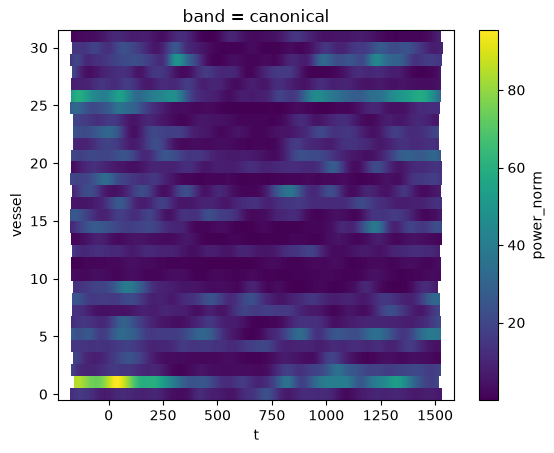

In [138]:
data_rat['power_norm'].sel( band='canonical').plot.imshow()

## Show BFI for all vessels. Colorcode low BFI as dark, high BFI as yellow

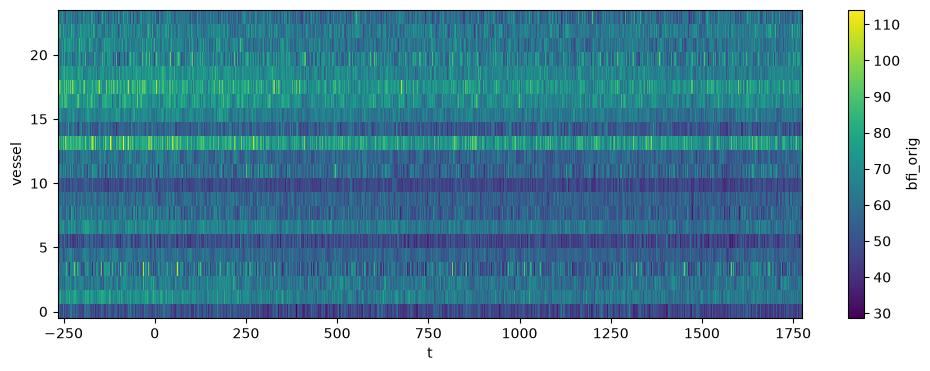

In [119]:
data_rat['bfi_orig'].plot.imshow(figsize=(12,4))

## Show Power of oscillation for all vessels. Colorcode low power as dark, high power as yellow

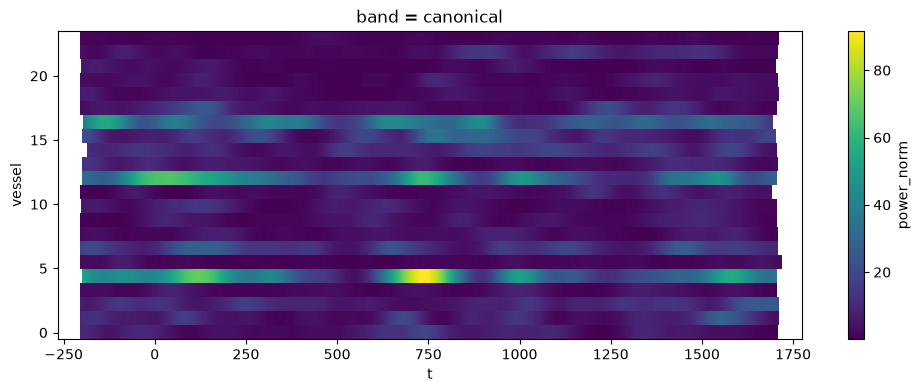

In [122]:
data_rat['power_norm'].sel(band='canonical').plot.imshow(figsize=(12,4))

## Another vessel, in which oscillations decrease after empagliflozin inejction (t=0 in all rats) 

In [125]:
# Convert to dataset to access all variables, just like with any other xr.dataset
data_rat = data['20241014a'].to_dataset() # alternatively, .ds method


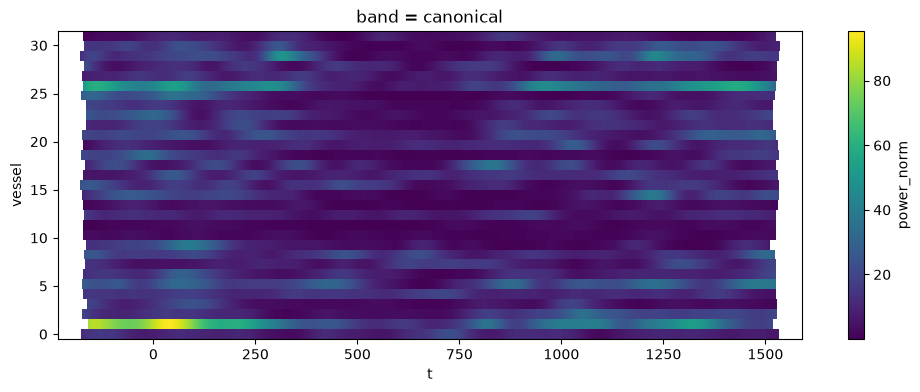

In [127]:
data_rat['power_norm'].sel(band='canonical').plot.imshow(figsize=(12,4))

[Text(0, 0.5, 'Norm. Power'), Text(0.5, 0, 'Time (s)')]

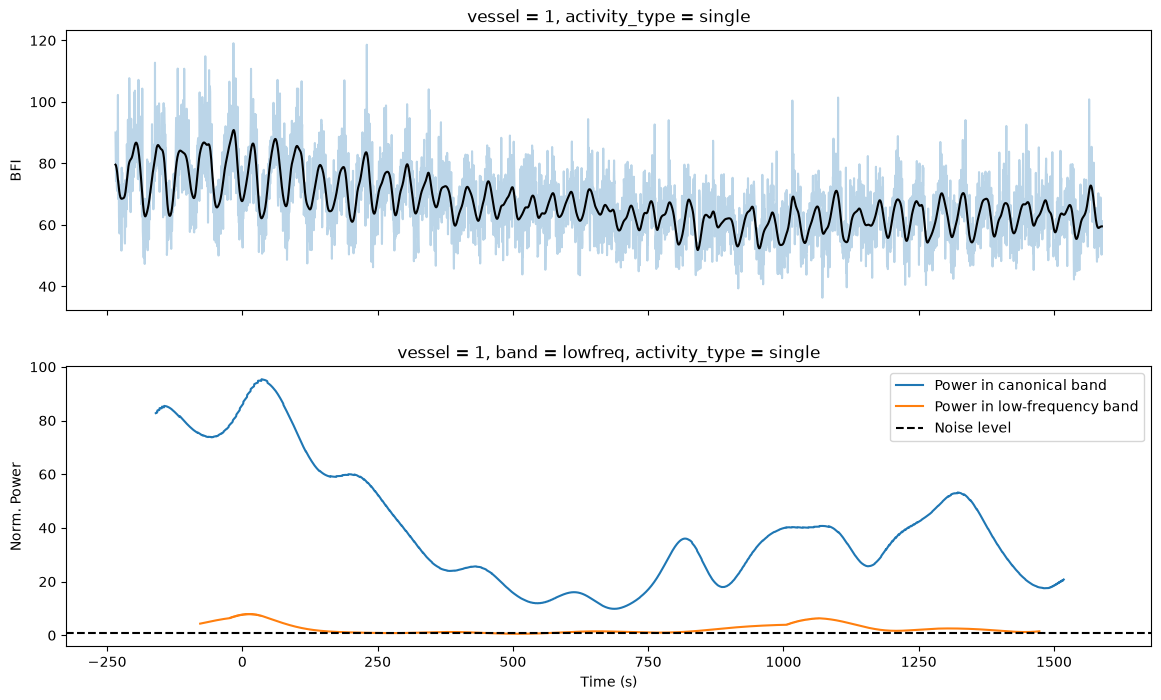

In [133]:
f, (ax,ax1) = plt.subplots(2,1, figsize=(14,8), sharex=True)
vessel_idx = 1
data_rat['bfi_orig'].sel(vessel=vessel_idx).plot(ax=ax, alpha=0.3)
gb_xr(data_rat['bfi_orig'].sel(vessel=vessel_idx), sigma=7).plot(ax=ax, color='k')
data_rat['power_norm'].sel(vessel=vessel_idx, band='canonical').plot(ax=ax1, label='Power in canonical band')
data_rat['power_norm'].sel(vessel=vessel_idx, band='lowfreq').plot(ax=ax1,label='Power in low-frequency band')

ax1.axhline(1, color='k', ls='--', label='Noise level')
ax1.legend()

ax.set(ylabel='BFI', xlabel='')
ax1.set(ylabel='Norm. Power', xlabel='Time (s)')

## Calculate mean Power at baseline and after injection

In [216]:
import sys
sys.path.append('../src/kidney')
import _timeseries_to_csv_oz as tsc
import plotting_oz as pz
import numpy as np

In [211]:
# bfi = tsc.make_table_with_bfi_response(da)
# bp = tsc.make_table_with_bp_response(da, time_stages=tsc.TIME_STGAES_BFI) #
power = tsc.make_table_with_power_response(data)
power['age'] = power.age.str.lower()
# freq = tsc.make_table_with_frequency_response(da)

# This functions average the given variable over time in specificed time intervals (one for BFI, a different one for power and frequency)

In [201]:
tsc.TIME_STGAES_BFI

{'baseline': {'t': slice(None, 0, None)},
 'response': {'t': slice(400, None, None)}}

In [205]:
tsc.TIME_STGAES_TGF

{'baseline': {'t': slice(None, 0, None)},
 'response': {'t': slice(400, 800, None)}}

#### Plot BFI and power time series for one vessel and mark time intervals used to compute the mean baseline and injected values of BFI and Power

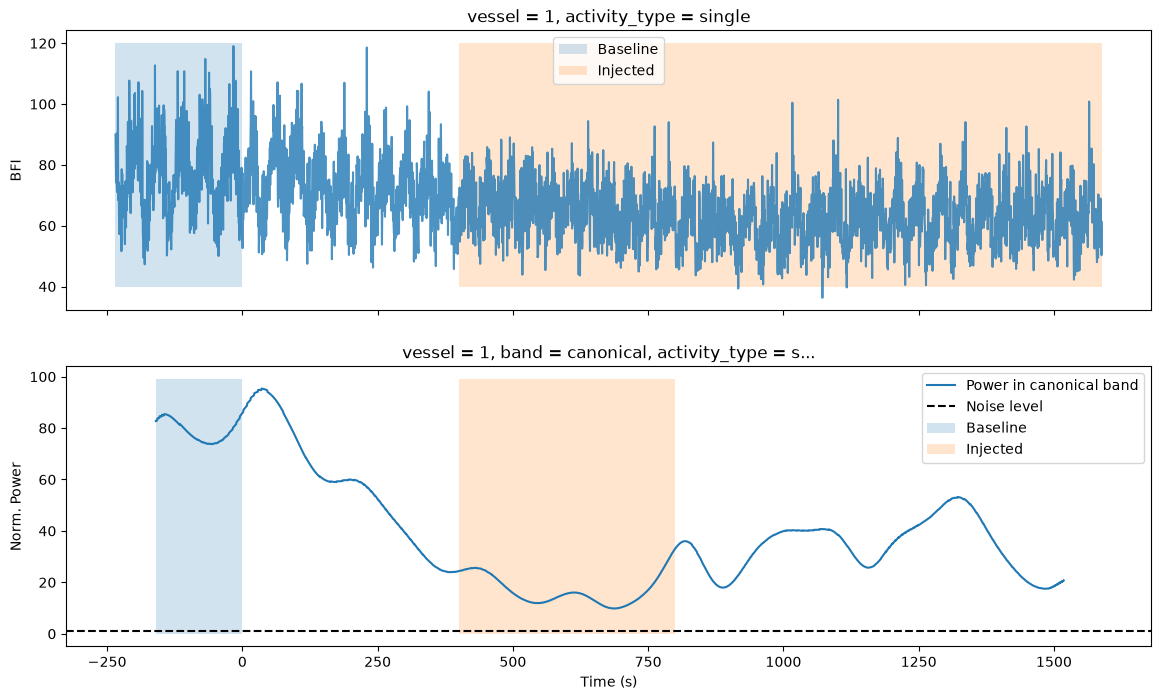

In [192]:
f, (ax,ax1) = plt.subplots(2,1, figsize=(14,8), sharex=True)
vessel_idx = 1
data_rat['bfi_orig'].sel(vessel=vessel_idx).plot(ax=ax, alpha=0.8)
# gb_xr(data_rat['bfi_orig'].sel(vessel=vessel_idx), sigma=7).plot(ax=ax, color='k')
data_rat['power_norm'].sel(vessel=vessel_idx, band='canonical').plot(ax=ax1, label='Power in canonical band')
# data_rat['power_norm'].sel(vessel=vessel_idx, band='lowfreq').plot(ax=ax1,label='Power in low-frequency band')

ax1.axhline(1, color='k', ls='--', label='Noise level')

ax.set(ylabel='BFI', xlabel='')
ax1.set(ylabel='Norm. Power', xlabel='Time (s)')


ax.fill_betweenx(y=[40,120], 
                  x1=data_rat['bfi_orig'].t.min(),
                  x2=tsc.TIME_STGAES_BFI['baseline']['t'].stop, alpha=0.2, label='Baseline')

ax.fill_betweenx(y=[40,120], 
                  x1=tsc.TIME_STGAES_BFI['response']['t'].start,
                  x2=data_rat['bfi_orig'].t.max(), alpha=0.2, label='Injected')

ax.legend()

ax1.fill_betweenx(y=[0,99], 
                  x1=data_rat['power_norm'].sel(vessel=vessel_idx, band='canonical').dropna('t').t.min(),
                  x2=tsc.TIME_STGAES_BFI['baseline']['t'].stop, alpha=0.2, label='Baseline')

ax1.fill_betweenx(y=[0,99], 
                  x1=tsc.TIME_STGAES_TGF['response']['t'].start,
                  x2=tsc.TIME_STGAES_TGF['response']['t'].stop, alpha=0.2, label='Injected')

ax1.legend()


## Show power measurements table

In [208]:
power

stage,rat,age,sex,gtyp,treatment,vessel,band,activity_type,baseline,response,change,change_log,baseline_log
0,20240813a,Young,M,fa/fa,empa,0,canonical,subthreshold,1.519565,0.713993,0.469867,-0.328025,0.181719
1,20240813a,Young,M,fa/fa,empa,0,lowfreq,subthreshold,1.767276,0.684590,0.387370,-0.411874,0.247304
2,20240813a,Young,M,fa/fa,empa,1,canonical,subthreshold,0.829137,1.155165,1.393213,0.144018,-0.081374
3,20240813a,Young,M,fa/fa,empa,1,lowfreq,subthreshold,1.378193,1.547324,1.122719,0.050271,0.139310
4,20240813a,Young,M,fa/fa,empa,2,canonical,subthreshold,1.048170,0.605394,0.577572,-0.238394,0.020432
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,20241030b,Adult,F,fa/fa,empa,11,lowfreq,single,0.992694,2.477531,2.495764,0.397203,-0.003184
1509,20241030b,Adult,F,fa/fa,empa,12,canonical,single,5.263543,4.580180,0.870171,-0.060396,0.721278
1510,20241030b,Adult,F,fa/fa,empa,12,lowfreq,single,1.180851,0.294004,0.248976,-0.603842,0.072195
1511,20241030b,Adult,F,fa/fa,empa,14,canonical,double,8.875301,9.485559,1.068759,0.028880,0.948183


[Text(0.5, 1.0, 'Baseline: Low frequency band'),
 Text(0.5, 0, 'Rats (random order)')]

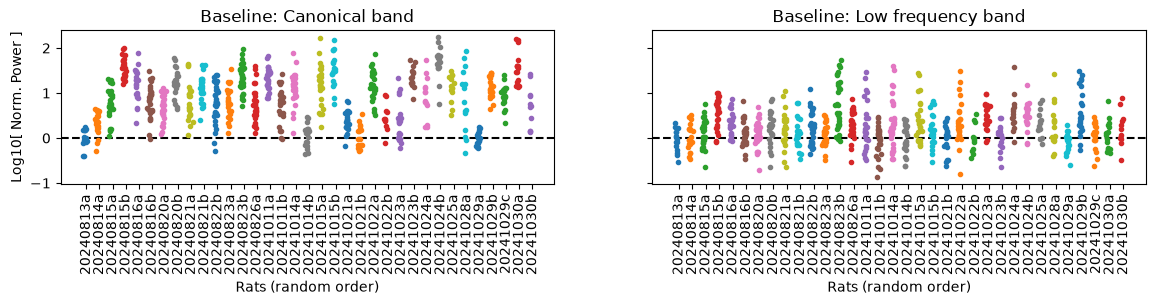

In [218]:
power['baseline_log'] = np.log10(power['baseline'])

f, axs = plt.subplots(1,2,figsize=(14,2), sharey=True)
jitter=0.08
shift=0.3
for axi in axs:
    axi.axhline(ls='--', color='k')
for (bnd, pp), ax in zip(power.groupby('band'), axs):

    xlabels = []
    xticks = []
    for i, (rat, grp) in enumerate(pp.groupby('rat')):
        y = grp['baseline_log'].values
        # y = np.log10(grp['pow_baseline'].values)
        x = i + jitter*np.random.randn(y.size)
        p = ax.plot(x,y, ls='', marker='.')
        xlabels.append(rat)
        xticks.append(i+shift/2)
    ax.set_xticks(xticks, xlabels, rotation=90)


axs[0].set(ylabel='Log10[ Norm. Power ]', title='Baseline: Canonical band', xlabel='Rats (random order)')
axs[1].set(title='Baseline: Low frequency band', xlabel='Rats (random order)')


## Baseline - All power values from the canonical band (not thresholded). Color indicates genotype

[Text(0, 0.5, 'Log[ Norm. baseline power ]')]

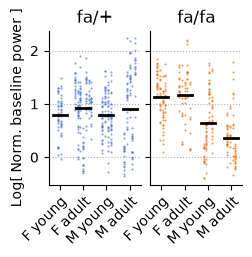

In [229]:
sele = (power.activity_type!='double')&(power.band=='canonical')
f, (ax,ax1) = pz.plot_panel(power[sele], 'baseline_log')
ax.set(ylabel='Log[ Norm. baseline power ]')

[Text(0, 0.5, 'Log[ Power change ]')]

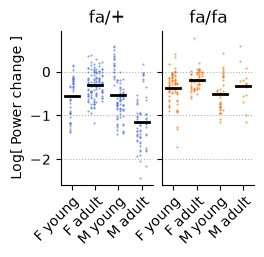

In [234]:
sele = (power.activity_type=='single')&(power.band=='canonical')
f, (ax,ax1) = pz.plot_panel(power[sele], 'change_log')
ax.set(ylabel='Log[ Power change ]')

# How do variables correlate with blood pressure?

### Blood pressure varies up and down between systolic/diastolic pressure. Block-averge it

In [269]:
t_aver = 200
# Rat in which correlation of frequency with blood pressure is prominent
data_rat = data['20241028a'].to_dataset()
data_rat_aver = data_rat.coarsen(t=t_aver, boundary='trim').mean()

### Show blood pressure trace

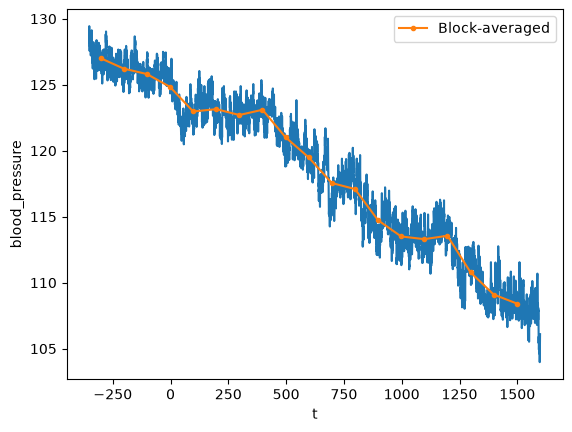

In [281]:
data_rat.blood_pressure.plot()
data_rat_aver.blood_pressure.plot(marker='.', label='Block-averaged')
plt.legend()

## Below, each plot represents one vessel. Time series of frequency is plot against time series of blood pressure (pressure is the same for all vessels). Time increases from dark to yellow points.

U:\SUN-BMI-HeartKidney\OlegZhukov\2024_Kidney_Empagliflozin\teddy-analysis\notebooks\../src/kidney\plotting_oz.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Text(0.5, 1.02, 'rat: 20241030b')

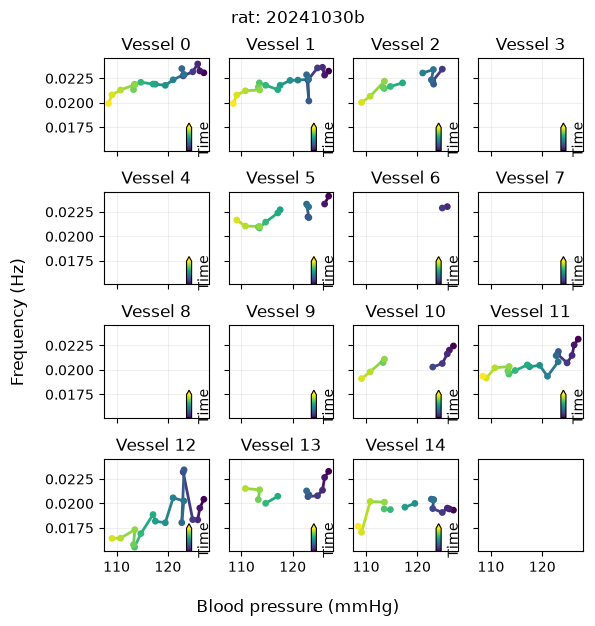

In [285]:
pz.plot_var_vs_bloodpressure(data_rat_aver, var='frequency', band='canonical', panel_size=1.5);
plt.suptitle(f"rat: {rat}", y=1.02)

### Normalized power against blood pressure

U:\SUN-BMI-HeartKidney\OlegZhukov\2024_Kidney_Empagliflozin\teddy-analysis\notebooks\../src/kidney\plotting_oz.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Text(0.5, 1.02, 'rat: 20241030b')

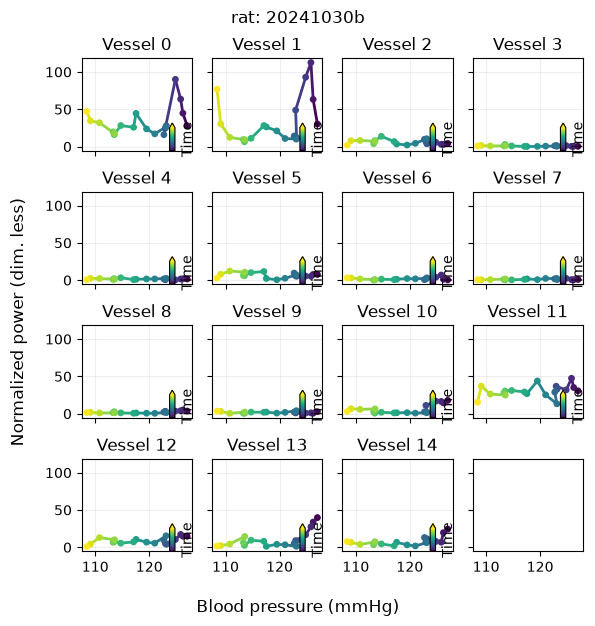

In [287]:
pz.plot_var_vs_bloodpressure(data_rat_aver, var='power_norm', band='canonical', panel_size=1.5);
plt.suptitle(f"rat: {rat}", y=1.02)

U:\SUN-BMI-HeartKidney\OlegZhukov\2024_Kidney_Empagliflozin\teddy-analysis\notebooks\../src/kidney\plotting_oz.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Text(0.5, 1.02, 'rat: 20241030b')

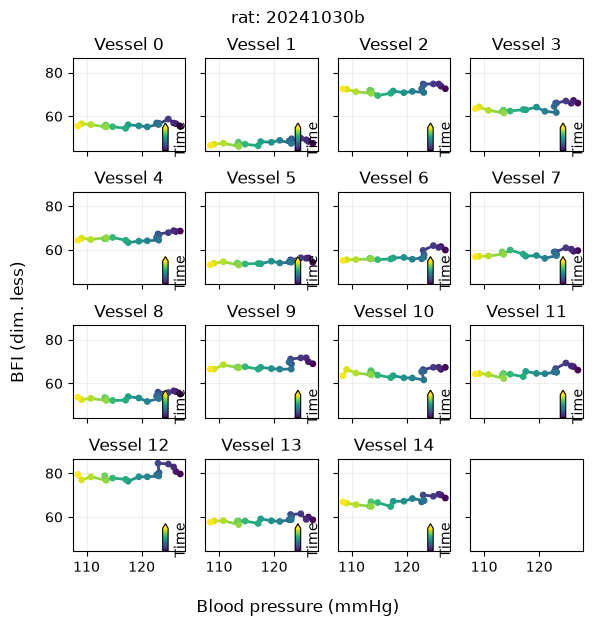

In [293]:
pz.plot_var_vs_bloodpressure(data_rat_aver, var='bfi_orig', panel_size=1.5);
plt.suptitle(f"rat: {rat}", y=1.02)